# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [23]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.2

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [24]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

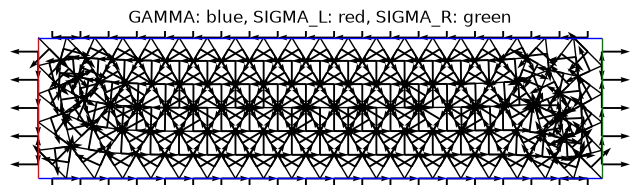

In [25]:
waveguide.plot()

In [26]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [27]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [28]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.LEFT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [29]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [30]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [31]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [32]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 13
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

3146

and an assembler:

In [33]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [34]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [35]:
A = P.assemble_LHS()

Interior: 100%|██████████| 338/338 [00:12<00:00, 28.00edge/s]


assembling local operators
region: Gamma


100%|██████████| 40/40 [00:00<00:00, 212.02edge/s]


region: Sigma_L


100%|██████████| 5/5 [00:00<00:00, 230.18edge/s]


region: Sigma_R


100%|██████████| 5/5 [00:00<00:00, 236.49edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 5/5 [00:10<00:00,  2.11s/edge]


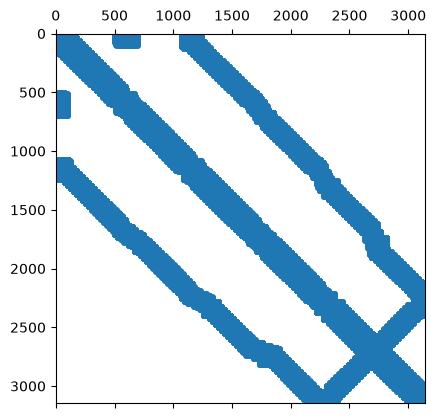

In [36]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [37]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [38]:
b = P.assemble_RHS()

In [39]:
P.solve()

In [40]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[-0.10333899+0.07823702j,  0.24078895+0.00463032j,
        -0.14077533-0.21676656j, ...,  0.00681655-0.20738795j,
         0.02137519+0.0826412j , -0.01394623-0.13220114j],
       [ 0.00410346-0.01895179j, -0.01557732+0.02537994j,
         0.0552499 +0.05722867j, ..., -0.0058834 +0.07046706j,
         0.02346774+0.02011728j,  0.01867042+0.01473674j],
       [ 0.32063222+0.65813695j,  0.42982045+0.08521349j,
         0.33211118+0.37442932j, ...,  0.06023151-0.0739498j ,
         0.08956051-0.09648624j,  0.60750707-0.19417503j],
       ...,
       [-0.04507973+0.00607781j,  0.05477723-0.02878984j,
         0.06595187-0.00745638j, ...,  0.00705736+0.06936957j,
         0.05902466+0.02014363j, -0.04527903+0.00250158j],
       [-0.03512645+0.04116163j,  0.01931419-0.02247259j,
         0.02867155+0.00991204j, ..., -0.01958357+0.04418885j,
         0.05850696+0.04022738j, -0.07314284+0.01566735j],
       [ 0.01724621+0.0603433j ,  0.01763182-0.0817839j ,
         0.04711038+0.05183641

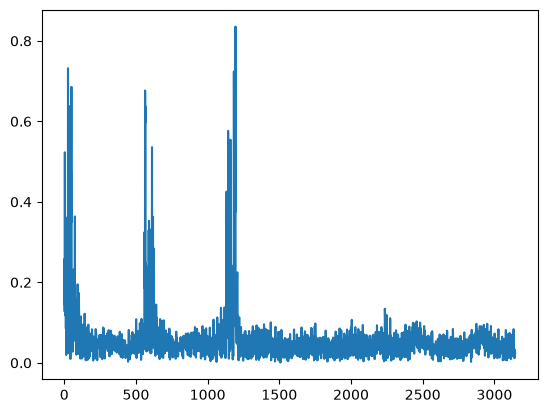

In [41]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [42]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

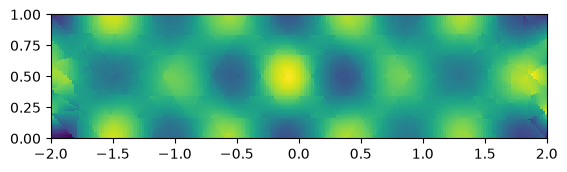

In [43]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

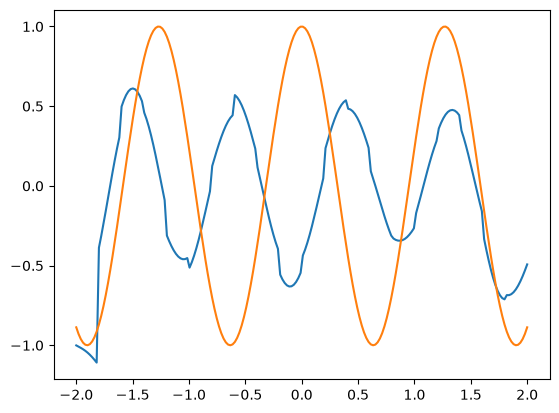

In [44]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)